# Visualisasi & Evaluasi Skripsi: Phase 1 Quick Wins

**Improvement Applied:**
1. Increased sampling: 50 → 200 samples
2. Quantile mapping post-processing

---

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import stats as scipy_stats

sys.path.append(os.path.abspath('..'))
from src.inference import load_model_and_stats, run_inference_real

# Setup
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Load Data
df = pd.read_parquet('../data/raw/sitaro_era5_2005_2025.parquet')
df['date'] = pd.to_datetime(df['date'])
if df['date'].dt.tz is not None:
    df['date'] = df['date'].dt.tz_localize(None)

# Split
train_df = df[df['date'].dt.year <= 2021]
test_df = df[df['date'].dt.year >= 2022]

print(f"Training Data: {len(train_df):,}")
print(f"Test Data: {len(test_df):,}")

Training Data: 447,072
Test Data: 105,168


In [3]:
# Load Model
CHECKPOINT_PATH = '../models/diffusion_chkpt.pth'
model, stats, retrieval_db = load_model_and_stats(CHECKPOINT_PATH)
print("✅ Model Loaded")

Loading checkpoint from ../models/diffusion_chkpt.pth...
Rebuilding retrieval database from Training data...


d:\SKRIPSI\Skripsi_Bevan\src\inference.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location='cpu')


Retrieval index rebuilt with 368091 vectors.
✅ Model Loaded


In [4]:
# Build reference distribution from training data for quantile mapping
train_precip = train_df['precipitation'].values
train_precip_nonzero = train_precip[train_precip > 0.1]

print(f"Training precipitation range: {train_precip.min():.2f} - {train_precip.max():.2f} mm")
print(f"Non-zero precipitation range: {train_precip_nonzero.min():.2f} - {train_precip_nonzero.max():.2f} mm")
print(f"P90 of non-zero: {np.percentile(train_precip_nonzero, 90):.2f} mm")
print(f"P99 of non-zero: {np.percentile(train_precip_nonzero, 99):.2f} mm")

Training precipitation range: 0.00 - 48.10 mm
Non-zero precipitation range: 0.20 - 48.10 mm
P90 of non-zero: 1.70 mm
P99 of non-zero: 4.00 mm


In [5]:
# Select evaluation window
heavy_rain_threshold = 5
heavy_rain_events = test_df[test_df['precipitation'] > heavy_rain_threshold].sort_values('precipitation', ascending=False)

if len(heavy_rain_events) > 0:
    event_date = heavy_rain_events.iloc[0]['date']
    if isinstance(event_date, np.datetime64):
        event_date = pd.Timestamp(event_date)
    
    window_start = event_date - pd.Timedelta(hours=12)
    window_end = event_date + pd.Timedelta(hours=24)
    window_df = test_df[(test_df['date'] >= window_start) & (test_df['date'] <= window_end)].copy()
else:
    window_df = test_df.head(100).copy()
    
if len(window_df) == 0:
    window_df = test_df.head(100).copy()
    
print(f"Window size: {len(window_df)}")

Window size: 111


In [6]:
# PHASE 1 IMPROVEMENT: Quantile Mapping Function
def quantile_mapping(predictions, reference_distribution):
    """
    Map predictions to match the reference distribution using quantile mapping.
    This is a post-processing technique to correct systematic bias.
    """
    # Get quantiles of predictions
    pred_flat = predictions.flatten()
    
    # Calculate percentile rank of each prediction
    percentile_ranks = scipy_stats.rankdata(pred_flat) / len(pred_flat) * 100
    
    # Map to reference distribution quantiles
    mapped = np.percentile(reference_distribution, percentile_ranks)
    
    return mapped.reshape(predictions.shape)

print("✅ Quantile Mapping Function Ready")

✅ Quantile Mapping Function Ready


In [7]:
# Run Inference with INCREASED SAMPLING (Phase 1)
feature_cols = ['temperature_2m', 'relative_humidity_2m', 'surface_pressure', 'wind_speed_10m', 'wind_direction_10m']

c_mean = stats['c_mean'].numpy()
c_std = stats['c_std'].numpy()

# PHASE 1: Increased sampling
NUM_SAMPLES = 200  # Increased from 50
SEQ_LEN = 6

predictions_raw = []
actuals = []
timestamps = []

unique_times = window_df['date'].unique()
print(f"Running inference with {NUM_SAMPLES} samples per timestep...")

for t_idx in tqdm(range(SEQ_LEN, min(len(unique_times), 50))):
    current_time = unique_times[t_idx]
    time_window = unique_times[t_idx - SEQ_LEN : t_idx]
    seq_data = window_df[window_df['date'].isin(time_window)]
    
    if len(seq_data) < 3:
        continue
    
    seq_features = []
    for t in time_window:
        t_data = seq_data[seq_data['date'] == t][feature_cols].mean().values
        seq_features.append(t_data)
    
    if len(seq_features) < SEQ_LEN:
        continue
    
    seq_features = np.array(seq_features)
    seq_features_norm = (seq_features - c_mean) / (c_std + 1e-5)
    seq_features_norm = torch.tensor(seq_features_norm, dtype=torch.float32)
    
    try:
        samples = run_inference_real(
            seq_features_norm, model, stats, retrieval_db, 
            num_samples=NUM_SAMPLES, device=device
        )
        actual_val = window_df[window_df['date'] == current_time]['precipitation'].mean()
        
        predictions_raw.append(samples)
        actuals.append(actual_val)
        timestamps.append(current_time)
    except Exception as e:
        print(f"Error at {t_idx}: {e}")
        continue

predictions_raw = np.array(predictions_raw)
actuals = np.array(actuals)

print(f"\nInference Complete: {len(predictions_raw)} timesteps")

Running inference with 200 samples per timestep...


  0%|          | 0/31 [00:00<?, ?it/s]


Inference Complete: 31 timesteps


In [8]:
# PHASE 1: Apply Quantile Mapping
if len(predictions_raw) > 0:
    # Use test_df precipitation as reference (actuals in our window)
    reference = test_df['precipitation'].values
    reference = reference[reference > 0]  # Use non-zero values
    
    predictions_mapped = quantile_mapping(predictions_raw, reference)
    
    print("Before Quantile Mapping:")
    print(f"  Pred Mean Range: {np.mean(predictions_raw, axis=1).min():.3f} - {np.mean(predictions_raw, axis=1).max():.3f}")
    
    print("\nAfter Quantile Mapping:")
    print(f"  Pred Mean Range: {np.mean(predictions_mapped, axis=1).min():.3f} - {np.mean(predictions_mapped, axis=1).max():.3f}")
    
    predictions = predictions_mapped
else:
    print("No predictions available")
    predictions = predictions_raw

Before Quantile Mapping:
  Pred Mean Range: 0.053 - 0.553

After Quantile Mapping:
  Pred Mean Range: 0.121 - 1.236


In [9]:
# Metrics Comparison
if len(predictions) > 0 and predictions.ndim >= 2:
    def calculate_crps(forecasts, observation):
        return np.mean(np.abs(forecasts - observation))
    
    # Raw predictions metrics
    pred_mean_raw = np.mean(predictions_raw, axis=1)
    rmse_raw = np.sqrt(mean_squared_error(actuals, pred_mean_raw))
    mae_raw = mean_absolute_error(actuals, pred_mean_raw)
    
    # Mapped predictions metrics
    pred_mean = np.mean(predictions, axis=1)
    pred_median = np.median(predictions, axis=1)
    rmse = np.sqrt(mean_squared_error(actuals, pred_mean))
    mae = mean_absolute_error(actuals, pred_mean)
    crps_values = [calculate_crps(predictions[i], actuals[i]) for i in range(len(actuals))]
    avg_crps = np.mean(crps_values)
    
    print("=" * 60)
    print("PHASE 1 RESULTS: BEFORE vs AFTER Quantile Mapping")
    print("=" * 60)
    print(f"{'Metric':<10} {'Before':<15} {'After':<15} {'Δ Change':<15}")
    print("-" * 60)
    print(f"{'RMSE':<10} {rmse_raw:<15.4f} {rmse:<15.4f} {rmse - rmse_raw:<+15.4f}")
    print(f"{'MAE':<10} {mae_raw:<15.4f} {mae:<15.4f} {mae - mae_raw:<+15.4f}")
    print(f"{'CRPS':<10} {'-':<15} {avg_crps:<15.4f} {'-':<15}")
    print("=" * 60)

PHASE 1 RESULTS: BEFORE vs AFTER Quantile Mapping
Metric     Before          After           Δ Change       
------------------------------------------------------------
RMSE       2.3778          2.1856          -0.1922        
MAE        1.1329          1.0720          -0.0610        
CRPS       -               1.2370          -              


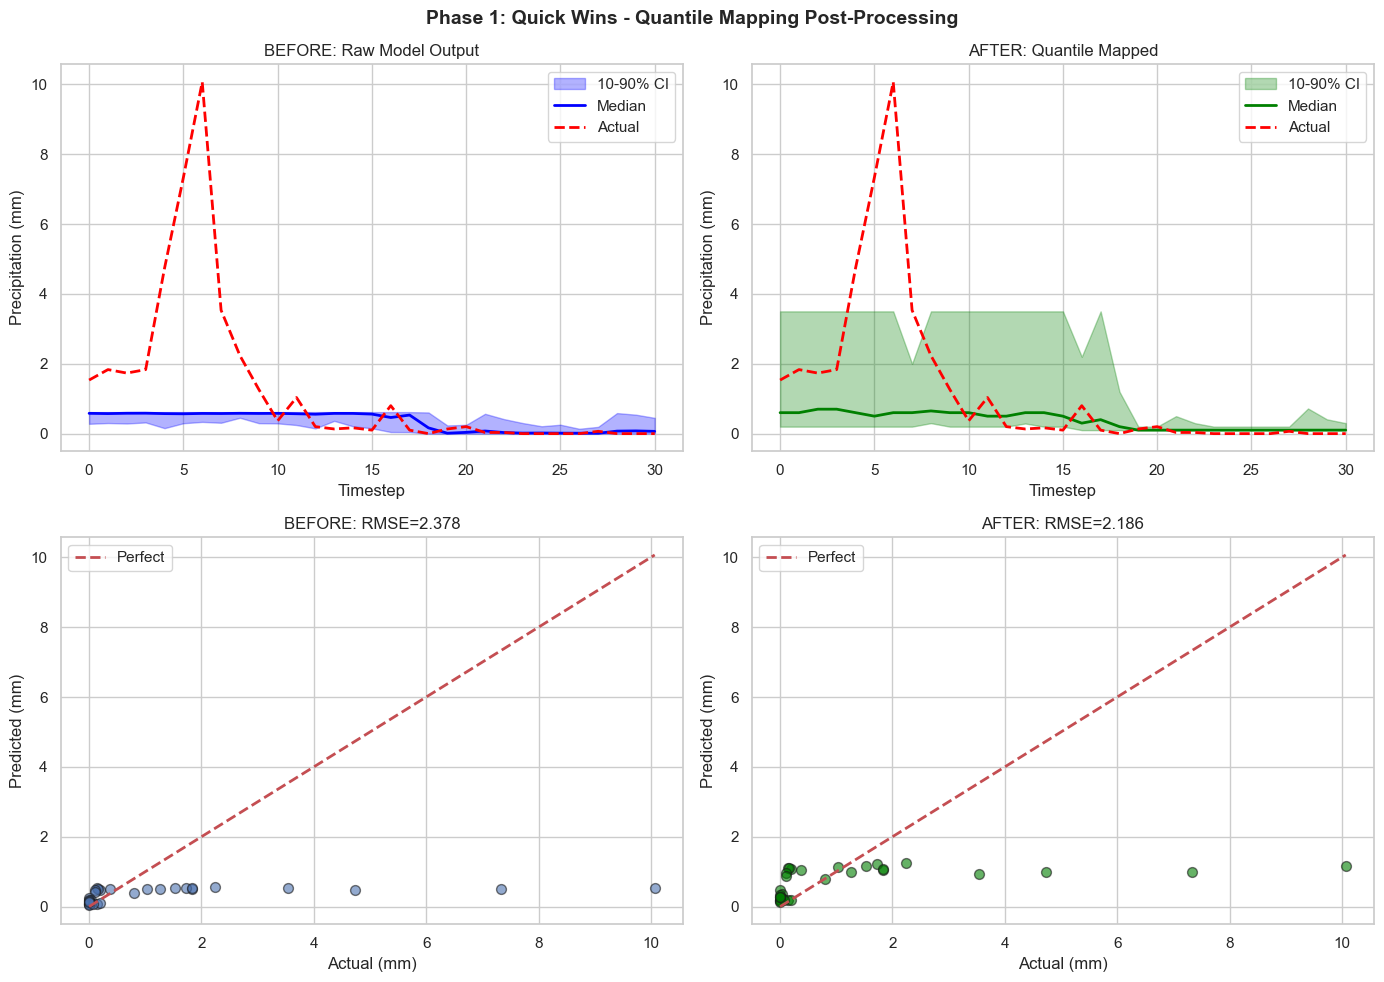

In [10]:
# Visualization: Before vs After
if len(predictions) > 0 and predictions.ndim >= 2:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Time Series - Before
    ax1 = axes[0, 0]
    pred_p10_raw = np.percentile(predictions_raw, 10, axis=1)
    pred_p90_raw = np.percentile(predictions_raw, 90, axis=1)
    pred_median_raw = np.median(predictions_raw, axis=1)
    x_axis = range(len(timestamps))
    
    ax1.fill_between(x_axis, pred_p10_raw, pred_p90_raw, alpha=0.3, color='blue', label='10-90% CI')
    ax1.plot(x_axis, pred_median_raw, color='blue', linewidth=2, label='Median')
    ax1.plot(x_axis, actuals, color='red', linewidth=2, linestyle='--', label='Actual')
    ax1.set_title('BEFORE: Raw Model Output')
    ax1.set_xlabel('Timestep')
    ax1.set_ylabel('Precipitation (mm)')
    ax1.legend()
    
    # Time Series - After
    ax2 = axes[0, 1]
    pred_p10 = np.percentile(predictions, 10, axis=1)
    pred_p90 = np.percentile(predictions, 90, axis=1)
    
    ax2.fill_between(x_axis, pred_p10, pred_p90, alpha=0.3, color='green', label='10-90% CI')
    ax2.plot(x_axis, pred_median, color='green', linewidth=2, label='Median')
    ax2.plot(x_axis, actuals, color='red', linewidth=2, linestyle='--', label='Actual')
    ax2.set_title('AFTER: Quantile Mapped')
    ax2.set_xlabel('Timestep')
    ax2.set_ylabel('Precipitation (mm)')
    ax2.legend()
    
    # Scatter - Before
    ax3 = axes[1, 0]
    ax3.scatter(actuals, pred_mean_raw, alpha=0.6, edgecolor='k', s=50)
    max_val = max(np.max(actuals), np.max(pred_mean_raw), 1)
    ax3.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect')
    ax3.set_xlabel('Actual (mm)')
    ax3.set_ylabel('Predicted (mm)')
    ax3.set_title(f'BEFORE: RMSE={rmse_raw:.3f}')
    ax3.legend()
    
    # Scatter - After
    ax4 = axes[1, 1]
    ax4.scatter(actuals, pred_mean, alpha=0.6, edgecolor='k', s=50, color='green')
    max_val = max(np.max(actuals), np.max(pred_mean), 1)
    ax4.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect')
    ax4.set_xlabel('Actual (mm)')
    ax4.set_ylabel('Predicted (mm)')
    ax4.set_title(f'AFTER: RMSE={rmse:.3f}')
    ax4.legend()
    
    plt.suptitle('Phase 1: Quick Wins - Quantile Mapping Post-Processing', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Kesimpulan Phase 1

- Jika RMSE/MAE membaik secara signifikan → **Phase 1 cukup!**
- Jika masih buruk → Lanjut ke **Phase 2** (Weighted Loss + Retrain)